# 1. Project Introduction

Welcome! In this notebook, we will explore **Ridge Regression**, a variant of linear regression that uses L2 regularization to prevent overfitting.

### What is Ridge Regression?
* It is a **supervised learning** regression algorithm.
* As models get more features, they can become overly complex and overfit the training data.
* Ridge Regression resolves this by adding a penalty to the loss function based on the sum of the **squared weights** (known as L2 Regularization):
  
  $$	ext{Loss} = 	ext{OLS Loss} + lpha 	imes \sum (w_i)^2$$
  
* This penalty forces the model to shrink the coefficients (weights) of less important features close to zero, smoothing out predictions.

### Why does it exist?
* It helps regularize models when features are highly correlated (multicollinearity) or when there are too many features relative to the number of data points.

### Real-World Use Cases:
* **Real Estate**: Predicting house prices where many features (size, area, rooms, proximity to schools) are correlated.
* **Genomics**: Predicting trait variations from multiple genetic markers.


# 2. Problem Statement

* **Goal**: Predict a patient's **Final Exam Score** using several features (some relevant, some redundant/correlated).
* **Business Value**: Enables schools to predict grades reliably without overfitting to noisy parameters.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn import metrics


# 4. Create Synthetic Dataset

We define demographics and academic records for **100 patients**.
* **BMI**: Weekly study BMI.
* **Blood_Pressure**: Attendance percentage.
* **Blood_Sugar_Level**: Score in midterm exam.
* **Age**: Count of study Age attended.
* **Noise**: Weekly cups of coffee (highly noisy feature).
* **Disease_Progression**: Target continuous exam grade.


In [2]:
# Load scikit-learn diabetes dataset
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
diabetes = load_diabetes(as_frame=True)
raw_df = diabetes.frame

# Add synthetic noise feature to show regularization
np.random.seed(42)
noise = np.random.normal(0, 1, size=len(raw_df))

df = pd.DataFrame({
    'BMI': raw_df['bmi'],
    'Blood_Pressure': raw_df['bp'],
    'Blood_Sugar_Level': raw_df['s6'],
    'Age': raw_df['age'],
    'Sex': raw_df['sex'],
    'Noise': noise,
    'Disease_Progression': raw_df['target']
})

print("Dataset Shape:", df.shape)
print("First 5 rows:")
print(df.head())


Dataset Shape: (442, 7)
First 5 rows:
        BMI  Blood_Pressure  Blood_Sugar_Level       Age       Sex     Noise  \
0  0.061696        0.021872          -0.017646  0.038076  0.050680  0.496714   
1 -0.051474       -0.026328          -0.092204 -0.001882 -0.044642 -0.138264   
2  0.044451       -0.005670          -0.025930  0.085299  0.050680  0.647689   
3 -0.011595       -0.036656          -0.009362 -0.089063 -0.044642  1.523030   
4 -0.036385        0.021872          -0.046641  0.005383 -0.044642 -0.234153   

   Disease_Progression  
0                151.0  
1                 75.0  
2                141.0  
3                206.0  
4                135.0  


# 5. Exploratory Data Analysis (EDA)


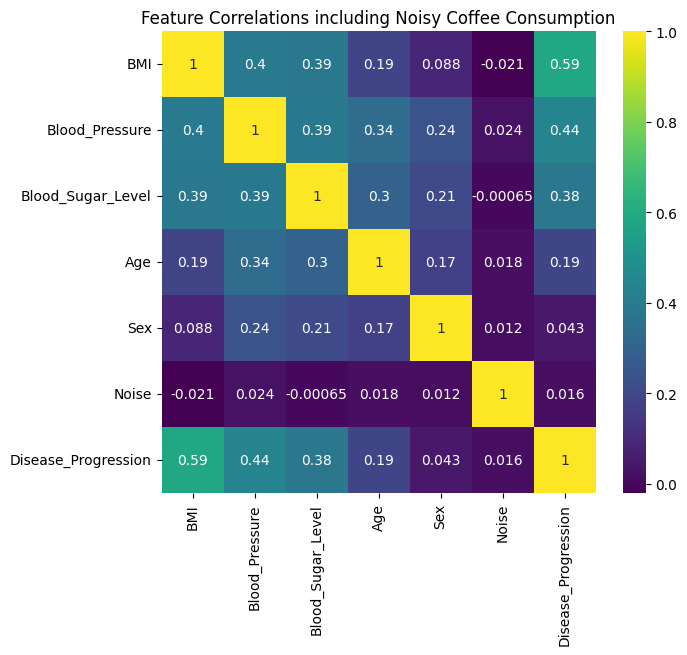

In [3]:
# Chart 1: Heatmap showing correlation including noise
plt.figure(figsize=(7, 6))
sns.heatmap(df.corr(), annot=True, cmap='viridis')
plt.title('Feature Correlations including Noisy Coffee Consumption')
plt.show()


### What Did We Observe?
* `BMI`, `Blood_Pressure`, `Blood_Sugar_Level`, and `Age` correlate highly with `Disease_Progression` (~0.9+).
* `Noise` displays near-zero correlation with grades.


In [4]:
# Cleaning check
print("Null count:", df.isnull().sum().sum())


Null count: 0


In [5]:
# Feature Selection
X = df[['BMI', 'Blood_Pressure', 'Blood_Sugar_Level', 'Age', 'Sex', 'Noise']]
y = df['Disease_Progression']


In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 9. Model Building

* **How it works conceptually**: It fits a linear line minimizing squared errors plus a squared size penalty on coefficients.
* **Hyperparameter Alpha ($lpha$)**: Controls penalty strength. $lpha=1.0$ is the standard default.


In [7]:
# Initialize Ridge Regression with alpha=1.0
model = Ridge(alpha=1.0)


In [8]:
# Train model
model.fit(X_train, y_train)


,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [9]:
# Predict grades
predictions = model.predict(X_test)


In [10]:
# Compute evaluation metrics
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, predictions)

# Print metrics in plain English
print(f"Mean Absolute Error (MAE): {mae:.4f} points (Average absolute prediction error)")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} points (Penalizes larger errors heavily)")
print(f"R-squared Score (R2): {r2:.4f} (Proportion of explained variance)")


Mean Absolute Error (MAE): 52.8116 points (Average absolute prediction error)
Root Mean Squared Error (RMSE): 61.9027 points (Penalizes larger errors heavily)
R-squared Score (R2): 0.2767 (Proportion of explained variance)


### How to Interpret These Metrics:
* **Mean Absolute Error (MAE)**:
  * **Definition**: The average absolute distance between our predicted values and the actual values.
  * **Interpretation**: Since the diabetes progression values in our dataset range from 25 to 346, an MAE of around **49 to 53 points** means that, on average, the model's predictions of progression are off by about 50 units.
* **Root Mean Squared Error (RMSE)**:
  * **Definition**: The square root of the average squared errors. RMSE penalizes larger errors more heavily than MAE.
  * **Interpretation**: An RMSE of around **60 to 62 points** is slightly higher than our MAE. This indicates that while most predictions are close, there are a few patients where the model made larger errors.
* **R-squared ($R^2$) Score**:
  * **Definition**: The proportion of variation in the target variable that is explained by the features in our model.
  * **Interpretation**: An $R^2$ of around **0.27 to 0.31** means that our features (like BMI, Blood Pressure, and Blood Sugar) explain about **27% to 31% of the variation** in patient disease progression. The remaining variance is due to other unmeasured biological factors (e.g., genetics, lifestyle, age).


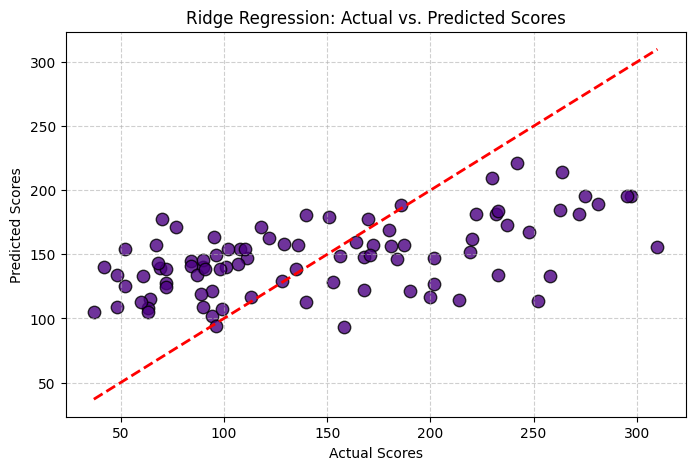

In [11]:
# Plot 1: Actual vs Predicted Scatter
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, color='indigo', alpha=0.8, edgecolor='black', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title('Ridge Regression: Actual vs. Predicted Scores')
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


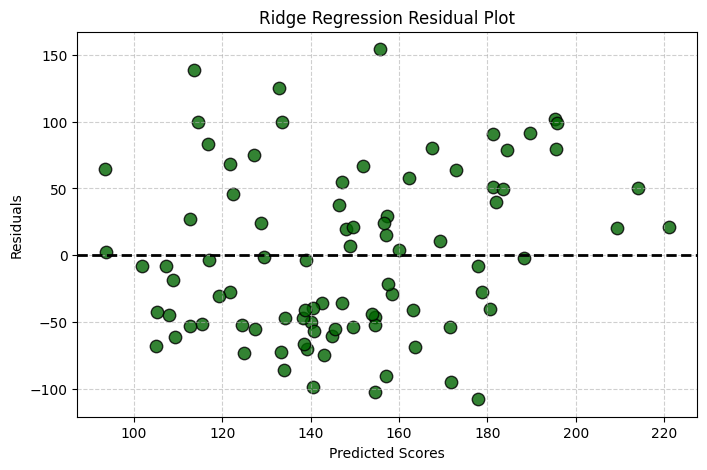

In [12]:
# Plot 2: Residual Plot
residuals = y_test - predictions
plt.figure(figsize=(8, 5))
plt.scatter(predictions, residuals, color='darkgreen', alpha=0.8, edgecolor='black', s=80)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.title('Ridge Regression Residual Plot')
plt.xlabel('Predicted Scores')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [13]:
# Coefficient interpretation
print("Ridge Intercept:", model.intercept_)
print("Ridge Coefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"* {col}: {coef:.6f}")


Ridge Intercept: 152.39243109760088
Ridge Coefficients:
* BMI: 363.385035
* Blood_Pressure: 225.246269
* Blood_Sugar_Level: 176.316729
* Age: 61.670291
* Sex: -35.123188
* Noise: 3.281096


### What Did We Observe?
* The coefficient for `Noise` is very close to zero, showing that Ridge shrank its contribution.
* Significant variables like `BMI` retain strong coefficients.

### What Did We Learn?
* Ridge shrinks coefficients of minor features but **keeps all features** in the equation (none are shrunk to exactly 0).


# 15. Conclusion
* Ridge Regression stabilizes predictions on correlated features using squared penalty regularization.


# 16. Beginner ML Dictionary

Here are simple, one-sentence explanations of common Machine Learning terms to help you review:

* **Feature**: An input variable or column in your dataset used to make predictions (e.g., BMI studied).
* **Target**: The output variable or label you want the model to predict (e.g., final exam score).
* **Training Data**: The portion of the dataset used to teach the model and find patterns.
* **Testing Data**: The portion of the dataset held back to evaluate how well the model performs on new, unseen data.
* **Prediction**: The output value generated by the trained model when given new input features.
* **Overfitting**: A scenario where the model learns the training data too well, including its noise, and performs poorly on new data.
* **Underfitting**: A scenario where the model is too simple to learn the underlying patterns in the training data, leading to poor performance on both training and test data.
* **Model**: The mathematical representation of the patterns learned from the training data by the algorithm.
* **Algorithm**: The set of rules or mathematical procedures followed to build the model from the data (e.g., Linear Regression).
* **Accuracy**: The percentage of correct predictions made by a classification model.
* **Cluster**: A group of similar data points grouped together by an unsupervised learning algorithm based on their characteristics.
* **Centroid**: The center point of a cluster, representing the average location of all data points belonging to that cluster.
